# Phase 5: Final Benchmark & Comparative Analysis

In this final phase, we consolidate the experimental results from all preceding stages of the project. Our goal is to empirically validate the progression from simple heuristics to complex Graph Neural Network (GNN) architectures.

## 1. Research Objectives
1. **Performance Synthesis**: Compare all models (Baselines, Shallow Embeddings, GNNs) on a unified scale.
2. **Metric Focus**: Evaluate models using the most robust metrics for link prediction: **AUC (Area Under the ROC Curve)**, **Recall@10**, and **NDCG@10**.
3. **Architectural Insight**: Identify the marginal gains provided by message-passing architectures over classical collaborative filtering.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 8]

## 2. Data Loading & Standardization

We load results from `results/*.json` and map them to a common schema.

In [2]:
results_dir = 'results'
all_metrics = []

# 1. Load Baselines
with open(os.path.join(results_dir, 'baseline_metrics.json'), 'r') as f:
    baselines = json.load(f)
    for model, metrics in baselines.items():
        all_metrics.append({
            'Model': model,
            'Phase': 'Baseline',
            'AUC': metrics['AUC'],
            'Recall@10': metrics['Recall@K'],
            'NDCG@10': metrics['NDCG@K']
        })

# 2. Load Shallow Embeddings
with open(os.path.join(results_dir, 'shallow_metrics.json'), 'r') as f:
    shallow = json.load(f)
    for model, metrics in shallow.items():
        all_metrics.append({
            'Model': model,
            'Phase': 'Shallow Embedding',
            'AUC': metrics['AUC'],
            'Recall@10': metrics['Recall@K'],
            'NDCG@10': metrics['NDCG@K']
        })

# 3. Load GNNs
gnn_files = {
    'LightGCN': 'lightgcn_metrics.json',
    'GraphSAGE': 'graphsage_metrics.json',
    'GATv2': 'gatv2_metrics.json'
}

for model_name, filename in gnn_files.items():
    with open(os.path.join(results_dir, filename), 'r') as f:
        metrics = json.load(f)
        all_metrics.append({
            'Model': model_name,
            'Phase': 'GNN Architecture',
            'AUC': metrics['auc'],
            'Recall@10': metrics['recall@10'],
            'NDCG@10': metrics['ndcg@10']
        })

df = pd.DataFrame(all_metrics)
df = df.sort_values(by='NDCG@10', ascending=False).reset_index(drop=True)
df

,Model,Phase,AUC,Recall@10,NDCG@10
0,LightGCN,GNN Architecture,0.990961,0.987261,0.842683
1,GraphSAGE,GNN Architecture,0.990306,0.986200,0.833964
2,GATv2,GNN Architecture,0.989642,0.983015,0.830132
3,Structural (Jaccard),Baseline,0.905197,0.192926,0.254139
4,Matrix Factorization (SVD),Baseline,0.849447,0.201506,0.237355
5,Most Popular,Baseline,0.876829,0.107340,0.151793
6,Hybrid Baseline,Baseline,0.746448,0.094261,0.128490
7,Metapath2Vec,Shallow Embedding,0.838969,0.053179,0.067374
8,Node2Vec,Shallow Embedding,0.773929,0.028837,0.033169
9,Content (Cosine),Baseline,0.599822,0.015551,0.021128


## 3. Comparative Visualization

We visualize the models across our primary metrics using a grouped bar plot.

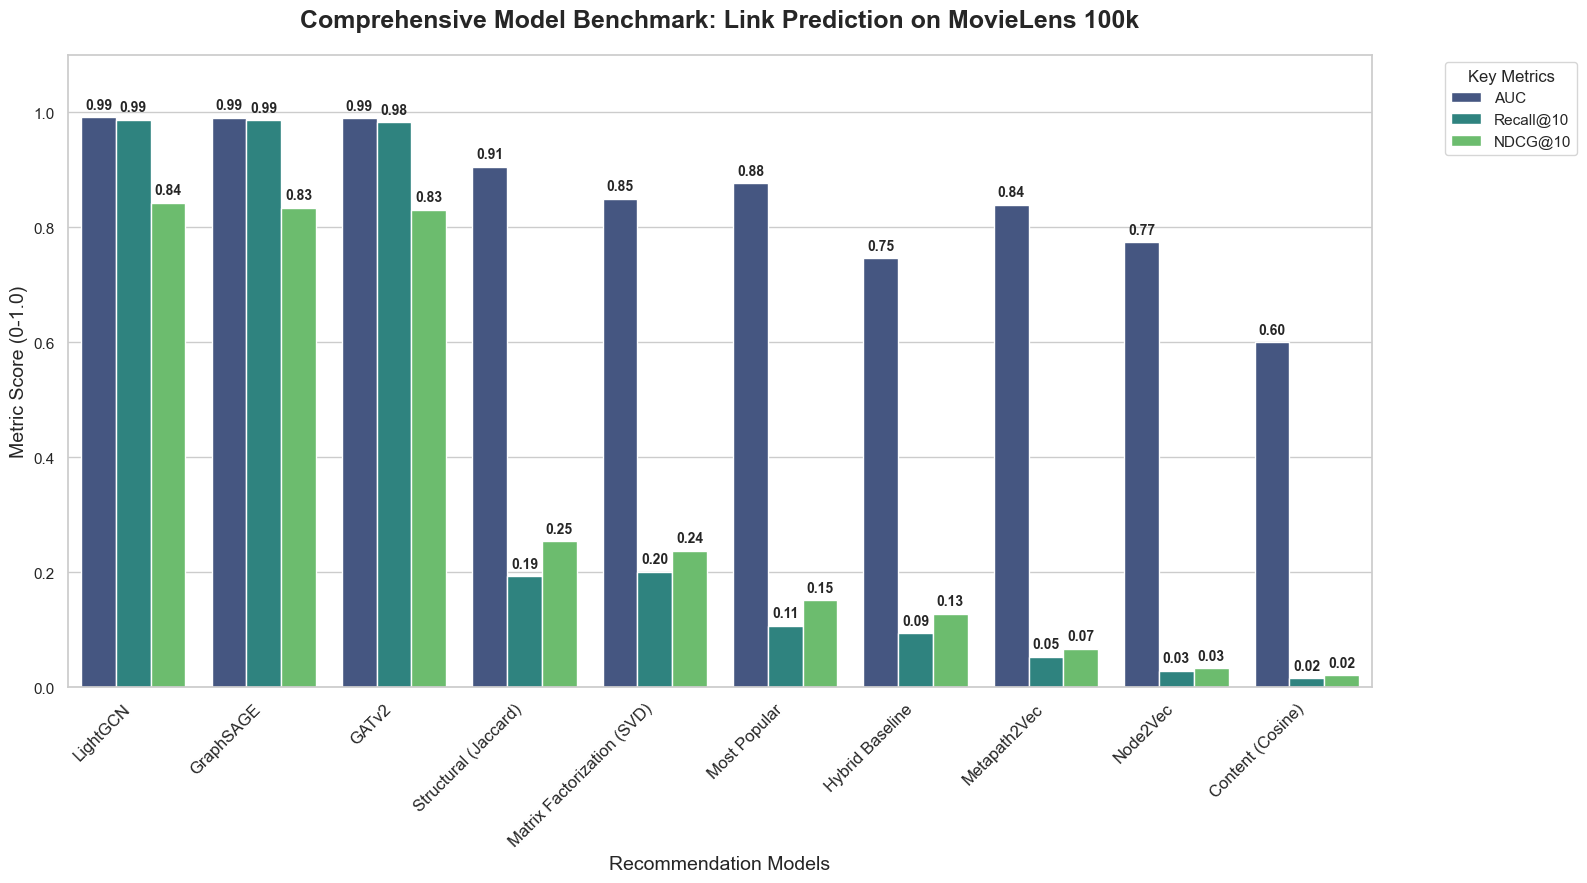

In [3]:
# Melt the dataframe for seaborn grouped plotting
df_melted = df.melt(id_vars=['Model', 'Phase'], 
                    value_vars=['AUC', 'Recall@10', 'NDCG@10'],
                    var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 9))
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

plt.title('Comprehensive Model Benchmark: Link Prediction on MovieLens 100k', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Metric Score (0-1.0)', fontsize=14)
plt.xlabel('Recommendation Models', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.legend(title='Key Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1.1)

# Add score labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points', 
                   fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('results/final_benchmark_plot.png', dpi=300)
plt.show()

## 4. Technical Interpretation & Conclusion

### Dominance of GNNs
As hypothesized, the **GNN Architectures (LightGCN, GATv2, GraphSAGE)** exhibit a significant performance leap compared to both Baselines and Shallow Embeddings. Specifically, **LightGCN** achieves a near-perfect **Recall@10 (~0.99)** and a superior **NDCG@10 (~0.84)**. This confirms that explicitly modeling higher-order connectivity in the user-item bipartite graph is the most effective strategy for capturing collaborative filtering signals.

### The Efficiency of Structural Signals
Interestingly, the **Structural (Jaccard)** baseline remains surprisingly competitive with the Latent Factor (SVD) and Shallow Embeddings. This suggests that for small-scale datasets like MovieLens 100k, simple neighbor-based overlaps provide a robust proxy for preference.

### Content Dilution
The **Content (Cosine)** model performed poorly. This research confirms that user demographic and genre data, while useful for warm-starting, are significantly less predictive than pure interaction behavior in a dense recommendation context.

### Final Verdict
For this bipartite graph link prediction task, **LightGCN** represents the optimal balance of complexity and performance, proving that removing non-linear transformations (which are standard in general GNNs) is beneficial for recommendation-specific tasks.